In [3]:

# =========================================================
# TEST download_api_data.py
# =========================================================

import sys
from pathlib import Path

# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT))

from src.download_api_data import download_firms_data

gdf = download_firms_data()

gdf.head()


Step 2.1: Project root:
C:\Users\Damian\OneDrive - Universität Zürich UZH\26 FS\GEO876 - Spatial Programming\GEO876_Project

Output directory:
C:\Users\Damian\OneDrive - Universität Zürich UZH\26 FS\GEO876 - Spatial Programming\GEO876_Project\data\raw
Step 3: Requesting wildfire data from:
https://firms.modaps.eosdis.nasa.gov/api/area/csv/cce9957f998431b07b2b2501061fc6aa/VIIRS_NOAA21_NRT/world/3
Step 4: Data successfully downloaded.

Step 5: Dataset successfully loaded.
Number of wildfire detections: 56651

Step 6: Geometry column successfully created.

Step 7: First rows of dataset:
   latitude longitude bright_ti4  scan track    acq_date acq_time satellite  \
0  -8.00129  24.08851     301.61  0.51  0.41  2026-05-16        1       N21   
1  -8.00052  24.08664     303.61  0.51  0.41  2026-05-16        1       N21   
2  -7.92245  24.00043     324.85  0.51  0.41  2026-05-16        1       N21   
3   -7.9187  24.00102     331.47  0.51  0.41  2026-05-16        1       N21   
4  -7.89666  2

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,geometry
0,-8.00129,24.08851,301.61,0.51,0.41,2026-05-16,1,N21,VIIRS,n,2.0NRT,289.55,0.98,N,POINT (24.08851 -8.00129)
1,-8.00052,24.08664,303.61,0.51,0.41,2026-05-16,1,N21,VIIRS,n,2.0NRT,289.71,0.75,N,POINT (24.08664 -8.00052)
2,-7.92245,24.00043,324.85,0.51,0.41,2026-05-16,1,N21,VIIRS,n,2.0NRT,289.44,3.51,N,POINT (24.00043 -7.92245)
3,-7.9187,24.00102,331.47,0.51,0.41,2026-05-16,1,N21,VIIRS,n,2.0NRT,289.22,4.38,N,POINT (24.00102 -7.9187)
4,-7.89666,24.24693,301.6,0.52,0.42,2026-05-16,1,N21,VIIRS,n,2.0NRT,288.1,1.28,N,POINT (24.24693 -7.89666)


In [4]:
# =============================================================================
# NOTEBOOK TESTING FOR process_wildfire_data.py
# =============================================================================

# Import autoreload so notebook updates automatically
%load_ext autoreload
%autoreload 2

# =============================================================================
# IMPORT LIBRARIES
# =============================================================================

from pathlib import Path
import geopandas as gpd

# Import functions from processing script
from src.process_wildfire_data import (
    load_data,
    inspect_data,
    validate_crs,
    clean_columns,
    clean_datatypes,
    remove_invalid_geometries,
    remove_missing_values,
    filter_confidence,
    add_temporal_columns,
)

# =============================================================================
# DEFINE PATHS
# =============================================================================

PROJECT_ROOT = Path.cwd().parent

RAW_DATA_PATH = (
    PROJECT_ROOT / "data" / "raw" / "wildfires_raw.geojson"
)

# =============================================================================
# LOAD DATA
# =============================================================================

gdf = load_data(RAW_DATA_PATH)

# Quick preview
gdf.head()

2026-05-18 14:47:44,767 | INFO | Loading wildfire data...


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2026-05-18 14:47:45,793 | INFO | Loaded 56651 wildfire records.


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,geometry
0,-8.00129,24.08851,301.61,0.51,0.41,2026-05-16,1,N21,VIIRS,n,2.0NRT,289.55,0.98,N,POINT (24.08851 -8.00129)
1,-8.00052,24.08664,303.61,0.51,0.41,2026-05-16,1,N21,VIIRS,n,2.0NRT,289.71,0.75,N,POINT (24.08664 -8.00052)
2,-7.92245,24.00043,324.85,0.51,0.41,2026-05-16,1,N21,VIIRS,n,2.0NRT,289.44,3.51,N,POINT (24.00043 -7.92245)
3,-7.9187,24.00102,331.47,0.51,0.41,2026-05-16,1,N21,VIIRS,n,2.0NRT,289.22,4.38,N,POINT (24.00102 -7.9187)
4,-7.89666,24.24693,301.6,0.52,0.42,2026-05-16,1,N21,VIIRS,n,2.0NRT,288.1,1.28,N,POINT (24.24693 -7.89666)


In [5]:
inspect_data(gdf)

2026-05-18 14:47:51,846 | INFO | Inspecting dataset...
2026-05-18 14:47:51,846 | INFO | CRS: EPSG:4326
2026-05-18 14:47:51,847 | INFO | Columns: ['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'instrument', 'confidence', 'version', 'bright_ti5', 'frp', 'daynight', 'geometry']
2026-05-18 14:47:51,850 | INFO | Geometry type(s): <StringArray>
['Point']
Length: 1, dtype: str
2026-05-18 14:47:51,851 | INFO | Missing values:
2026-05-18 14:47:51,881 | INFO | latitude      0
longitude     0
bright_ti4    0
scan          0
track         0
acq_date      0
acq_time      0
satellite     0
instrument    0
confidence    0
version       0
bright_ti5    0
frp           0
daynight      0
geometry      0
dtype: int64


In [6]:
gdf = validate_crs(gdf)

gdf.crs

2026-05-18 14:47:54,605 | INFO | Validating CRS...
2026-05-18 14:47:54,606 | INFO | Original CRS: EPSG:4326
2026-05-18 14:47:54,636 | INFO | Reprojected to: EPSG:3857


<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [10]:
gdf = clean_columns(gdf)

gdf.columns

2026-05-18 14:50:28,617 | INFO | Cleaning columns...
2026-05-18 14:50:28,618 | INFO | Remaining columns: 7


Index(['latitude', 'longitude', 'acq_date', 'acq_time', 'confidence', 'frp',
       'geometry'],
      dtype='str')

In [11]:
gdf = clean_datatypes(gdf)

gdf.dtypes

2026-05-18 14:50:29,999 | INFO | Cleaning datatypes...


latitude             float64
longitude            float64
acq_date      datetime64[ms]
acq_time                 str
confidence               str
frp                  float64
geometry            geometry
dtype: object

In [12]:
gdf = remove_invalid_geometries(gdf)

gdf.is_valid.all()

2026-05-18 14:50:32,477 | INFO | Removing invalid geometries...
2026-05-18 14:50:32,479 | INFO | Removed 0 invalid geometries.


np.True_

In [13]:
gdf = remove_missing_values(gdf)

gdf.isna().sum()

2026-05-18 14:50:34,197 | INFO | Removing missing values...
2026-05-18 14:50:34,199 | INFO | Removed 0 rows with missing values.


latitude      0
longitude     0
acq_date      0
acq_time      0
confidence    0
frp           0
geometry      0
dtype: int64

In [14]:
gdf = filter_confidence(gdf)

gdf["confidence"].min()

2026-05-18 14:50:36,680 | INFO | Filtering confidence = h
2026-05-18 14:50:36,683 | INFO | Removed 0 low- and nominal-confidence detections.


'h'

In [15]:
gdf = add_temporal_columns(gdf)

gdf.head()

2026-05-18 14:50:40,415 | INFO | Adding temporal columns...


,latitude,longitude,acq_date,acq_time,confidence,frp,geometry,year,month,day
110,-7.51251,11.21977,2026-05-16,3,h,11.53,POINT (1248979.083 -838695.376),2026,5,16
451,4.65957,6.07647,2026-05-16,137,h,15.53,POINT (676429.546 519273.665),2026,5,16
497,40.53620,141.50447,2026-05-16,243,h,8.96,POINT (15752205.545 4944170.099),2026,5,16
509,44.24170,135.33273,2026-05-16,243,h,15.39,POINT (15065170.591 5502922.32),2026,5,16
524,50.38020,129.81967,2026-05-16,245,h,36.62,POINT (14451459.559 6512382.005),2026,5,16


<Axes: >

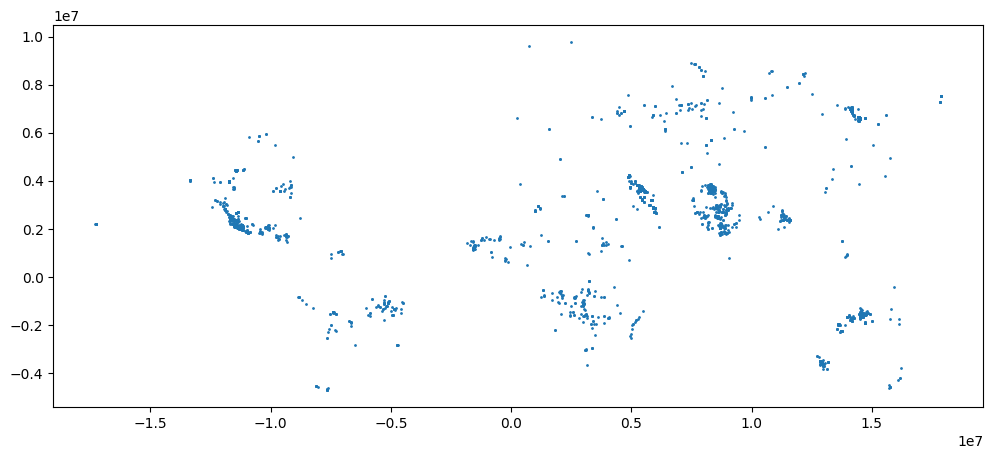

In [16]:
gdf.plot(
    figsize=(12, 8),
    markersize=1
)